-*- encoding: utf-8 -*-
This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni
GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.
You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

# kmin_kmax

Everything `IPSTools` builds is an integral of the input matter Power Spectrum over a
finite range $[k_\mathrm{min}, k_\mathrm{max}]$:

\begin{equation*}
  \sigma_i = \int_{k_\mathrm{min}}^{k_\mathrm{max}} \frac{\mathrm{d}q}{2\pi^2} \, q^{\,2-i} \, P(q)
  \;, \qquad
  I_\ell^n(s) = \int_{k_\mathrm{min}}^{k_\mathrm{max}} \frac{\mathrm{d}q}{2\pi^2} \, q^2 \, P(q) \,
    \frac{j_\ell(qs)}{(qs)^n} \; .
\end{equation*}

**They have to be the same range.** The two families are not independent: $j_0(qs) \to 1$
for $s \to 0$, so

\begin{equation*}
  I_0^0(s) \; \xrightarrow[s \, \rightarrow \, 0]{} \; \sigma_0 \; ,
\end{equation*}

and the $\Delta\chi \rightarrow 0$ limit of every $\chi$-integrated TPCF is exactly the
statement that a $J \cdot I_\ell^n$ sum can be replaced by a combination of $\sigma_i$.
If the two are computed on two different supports, the two branches are two different
functions, and the switch between them is a step - which is the 41% jump that
[`deltachi_limits`](deltachi_limits.ipynb) measures on Lensing-Lensing.

Until this branch `IPSTools` did exactly that: the five $\sigma_i$ used the `k_min` and
`k_max` it is given, while the `xicalc` that builds the nine $I_\ell^n$ and the `quadgk`
that builds $\tilde{I}^4_0$ were hard-coded to `1e-5, 1e3`. Now the input pair bounds all
of them.

This notebook is the check of what that costs, and of what moving the pair does. The
short version:

1. the $\sigma_i$ are *defined* by the cut: $\sigma_0$ grows without bound with
   $k_\mathrm{max}$ and $\sigma_4$ with $1/k_\mathrm{min}$, while $\sigma_1$, $\sigma_2$,
   $\sigma_3$ converge. Between the two ranges GaPSE used to mix, $\sigma_0$ differs by a
   factor **7.7**;
2. the $I_\ell^n$ are insensitive to the range for $s \gtrsim 2 \; h^{-1}\,$Mpc and
   sensitive below it, which is precisely the region where the $\Delta\chi \rightarrow 0$
   limits live;
3. **the power-law fit is the fragile part, and it does break.** With
   $k_\mathrm{max} = 10$ the left fit of $I_0^0$, $I_2^2$ and $I_1^1$ collapses onto a
   degenerate solution and the extrapolation below `fit_min` jumps by a factor $10^3$.
   The condition is simple - the fit window has to stay *outside* the saturated
   region, $\texttt{fit\_min} \gg 1/k_\mathrm{max}$ - and there is a defect in
   `power_law_from_data` that lets the collapse pass silently. Section 4;
4. the change is **not** free. What moves is the $I_\ell^n$ at small $s$ - with
   $k_\mathrm{max} = 10$, $I_0^0(0.06)$ is 57% of what it was and $I_0^0(0.1)$ is 70% -
   and that is exactly the region the $\Delta\chi \rightarrow 0$ switch feeds on. On the
   test cosmology the GNC Lensing-Lensing $L = 0$ multipole moves by up to 38% at
   $s = 10^3$, while the GNC sum moves by 0.5%. The reference files of the unit tests
   store the old mixed convention and have to be regenerated. Section 6.

All the output files are saved in the `kmin_kmax/` directory.

In [1]:
"""
    help(x)

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.
"""
macro help(x)
    quote
        display("text/markdown", @doc $x)
    end
end;
@help @help

```julia
help(x)
```

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.


## GaPSE setup

In [2]:
using GaPSE
using Plots, LaTeXStrings, QuadGK, DelimitedFiles, Printf
# GR, the default Plots backend: it needs no Python at all, and it is the one that
# works under Julia 1.12 - see the "Which backend" section of ../ipynbs/README.md
gr()

Plots.GRBackend()

In [3]:
const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."));
# Input matter Power Spectrum P(q) at z=0, and the files a full Cosmology needs
const FILE_PS = joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat");
const FILE_BACKGROUND = joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_background.dat");
const FILE_F_MAP = joinpath(PATH_TO_GAPSE, "data", "F_REFERENCE_pi2.txt");
const FILE_IF_MAP = joinpath(PATH_TO_GAPSE, "data", "IntegrF_REFERENCE_pi2_z005020.txt");

In [4]:
const DIR = joinpath(@__DIR__, "kmin_kmax");
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

In [5]:
# The `InputPS` extrapolates with a power law outside the range of the input file;
# these are the extremes of the tabulated data, i.e. where P(q) is measured and not
# extrapolated. Anything asked outside them is the fit talking.
const PS_TABLE = readdlm(FILE_PS, comments=true);
const K_DATA_MIN, K_DATA_MAX = extrema(PS_TABLE[:, 1]);

# the pair `IPSTools` used to hard-code for `xicalc`, and its default keyword pair
const KS_OLD_XICALC = (1e-5, 1e3);
const KS_DEFAULT = (1e-6, 10.0);

# the ranges scanned in the tables below
const RANGES = [(1e-5, 1e3), (1e-8, 1e3), (1e-8, 1e1), (1e-6, 1e1), (1e-7, 1e2), (1e-4, 1e4)];

In [6]:
const IPS = GaPSE.InputPS(FILE_PS);

# the eight (l, n) pairs `IPSTools` stores, and the five moments
const LNS = [(0, 0), (2, 0), (4, 0), (0, 2), (2, 2), (3, 1), (1, 3), (1, 1)];
const IS = [0, 1, 2, 3, 4];

rangelabel(kmin, kmax) = @sprintf("[%.0e, %.0e]", kmin, kmax)

rangelabel (generic function with 1 method)

## The moments and the integrals as a function of the range

In [7]:
"""
    σ(i, kmin, kmax)
    sigmas(kmin, kmax)

The i-th moment of the input Power Spectrum on `[kmin, kmax]`, and the five of them
`IPSTools` stores. Same `quadgk` call as the one inside the `IPSTools` constructor.
"""
σ(i, kmin, kmax) = quadgk(q -> IPS(q) * q^(2 - i) / (2 * π^2), kmin, kmax)[1]
sigmas(kmin, kmax) = [σ(i, kmin, kmax) for i in IS];
@help σ

```julia
σ(i, kmin, kmax)
sigmas(kmin, kmax)
```

The i-th moment of the input Power Spectrum on `[kmin, kmax]`, and the five of them `IPSTools` stores. Same `quadgk` call as the one inside the `IPSTools` constructor.


In [8]:
"""
    build_Ilns(kmin, kmax; N=1024, s0=1e-3, fit_min=0.05, fit_max=0.5, con=true)

The eight `IntegralIPS` of an `IPSTools`, built on `[kmin, kmax]` with the same keywords
the constructor uses. Returns a `Dict` keyed by the `(l, n)` pair.
"""
function build_Ilns(kmin, kmax; N=1024, s0=1e-3, fit_min=0.05, fit_max=0.5, con=true)
    p0 = con ? [-1.0, 1.0, 0.0] : [-1.0, 1.0]
    Dict((l, n) => GaPSE.IntegralIPS(IPS, l, n; N=N, kmin=kmin, kmax=kmax, s0=s0,
        fit_left_min=fit_min, fit_left_max=fit_max, p0_left=p0, con=con) for (l, n) in LNS)
end;

In [9]:
"""
    fit_branch(xs, ys, p0, fit_min, fit_max)

Which of the three branches of the `con=true` fit of `power_law_from_data` the data
`(xs, ys)` takes, and the *signed* relative errors of the three parameters that decide
it. `"if"` is the healthy one, where the three-parameter fit is kept; in the other two
the constant `a` is dropped.
"""
function fit_branch(xs, ys, p0, fit_min, fit_max)
    m = fit_min .< xs .< fit_max
    x, y = xs[m], ys[m]
    ex = 10.0^(-sum(log10.(abs.(x))) / length(x))
    ey = 10.0^(-sum(log10.(abs.(y))) / length(y))
    f = GaPSE.curve_fit((xx, p) -> GaPSE.power_law(xx, p[1], p[2], p[3]), x .* ex, y .* ey, p0)
    pers = GaPSE.stderror(f) ./ GaPSE.coef(f)
    br = all(z -> z < 0.05, pers) ? "if" : (pers[3] < 0.05 ? "elseif" : "else")
    br, pers
end;

## Plot and table functions

In [10]:
function plot_kwargs(kwargs...)
    dict_defaults = Dict(
        :size => (1000, 400), :dpi => 300, :legendposition => :outerright,
        :legendfontsize => 11, :guidefontsize => 14, :tickfontsize => 11,
        :titlefontsize => 16, :left_margin => 10Plots.mm,
    )
    # In "merge", if a key is repeated in the input dicts, the LAST collection value has priority
    merge(dict_defaults, Dict(kwargs))
end;

In [11]:
logticks(lo, hi; step=1) = 10.0 .^ (floor(Int, log10(lo)):step:ceil(Int, log10(hi)))

logticks (generic function with 1 method)

In [12]:
function save_plot(p, name)
    savefig(p, joinpath(DIR, name))
    nothing
end

save_plot (generic function with 1 method)

In [13]:
"""
    table_two_ranges(io=stdout)

The five ``\\sigma_i`` on the pair `IPSTools` takes as input and on the pair it used to
hard-code for `xicalc`, with their ratio.
"""
function table_two_ranges(io=stdout)
    a, b = sigmas(KS_DEFAULT...), sigmas(KS_OLD_XICALC...)
    @printf(io, "%-10s %16s %16s %10s\n", "", "the σ_i range", "the I_l^n range", "ratio")
    @printf(io, "%-10s %16s %16s %10s\n", "", rangelabel(KS_DEFAULT...),
        rangelabel(KS_OLD_XICALC...), "")
    for (k, i) in enumerate(IS)
        @printf(io, "sigma_%-4d %16.6e %16.6e %10.4f\n", i, a[k], b[k], b[k] / a[k])
    end
end;

In [14]:
"""
    table_left_fits(io=stdout; lns=[(0, 0), (2, 2), (1, 1)], ranges=RANGES)

The parameters of the LEFT power law of each `IntegralIPS`, the branch of
`power_law_from_data` that produced them, and the value the extrapolation returns just
below `fit_min`, where the spline stops. A healthy row has `l_a != 0` and a value
continuous with the spline.
"""
function table_left_fits(io=stdout; lns=[(0, 0), (2, 2), (1, 1)], ranges=RANGES,
    fit_min=0.05, fit_max=0.5)
    @printf(io, "%-18s %-8s %9s %12s %12s %8s %13s %13s\n", "k range", "I_l^n",
        "l_si", "l_b", "l_a", "branch", "spline(fmin)", "fit(0.9 fmin)")
    for (kmin, kmax) in ranges
        d = build_Ilns(kmin, kmax; fit_min=fit_min, fit_max=fit_max)
        for (l, n) in lns
            f = d[(l, n)]
            rs, xis = GaPSE.xicalc(IPS, l, n; N=1024, kmin=kmin, kmax=kmax, r0=1e-3)
            br, _ = fit_branch(rs, xis, [-1.0, 1.0, 0.0], fit_min, fit_max)
            @printf(io, "%-18s I_%d^%-5d %9.4f %12.4e %12.4e %8s %13.4e %13.4e\n",
                rangelabel(kmin, kmax), l, n, f.l_si, f.l_b, f.l_a, br,
                f(1.001 * fit_min), f(0.9 * fit_min))
        end
    end
end;

In [15]:
"""
    table_fit_windows(io=stdout; kmin=1e-8, kmax=10.0, windows=...)

The same LEFT fit of ``I_0^0``, with the fit window moved and the range held. The window
has to lie where ``I_0^0`` is still a power law, i.e. ABOVE the saturation scale
``1/k_\\mathrm{max}``; inside the saturated region the function is flat, and a flat
dataset is precisely what makes ``a + b \\, s^{s_i}`` degenerate.
"""
function table_fit_windows(io=stdout; kmin=1e-8, kmax=10.0,
    windows=[(0.05, 0.5), (0.2, 2.0), (0.5, 5.0), (1.0, 10.0), (2.0, 20.0)])
    @printf(io, "k_min = %.0e, k_max = %.0e  ->  saturation scale 1/k_max = %.3g\n",
        kmin, kmax, 1 / kmax)
    @printf(io, "%-21s %9s %12s %12s %14s %14s\n", "[fit_min, fit_max]", "l_si", "l_b",
        "l_a", "spline(fmin+)", "fit(0.9 fmin)")
    for (fmin, fmax) in windows
        f = GaPSE.IntegralIPS(IPS, 0, 0; N=1024, kmin=kmin, kmax=kmax, s0=1e-3,
            fit_left_min=fmin, fit_left_max=fmax, p0_left=[-1.0, 1.0, 0.0], con=true)
        @printf(io, "[%8.0e, %8.0e] %9.4f %12.4e %12.4e %14.4e %14.4e\n",
            fmin, fmax, f.l_si, f.l_b, f.l_a, f(1.001 * fmin), f(0.9 * fmin))
    end
end;

In [16]:
"""
    table_right_edges(io=stdout; ranges=RANGES)

Where the spline of each `IntegralIPS` stops. `xicalc` returns a logarithmic `s` grid
that starts at `s0` and spans `log10(kmax/kmin)` decades, and `IntegralIPS` takes its
last-but-one point as the edge: so the range decides it, and beyond it the right power
law takes over. A `right` below the largest separation GaPSE is asked for means the
right fit, not the integral, is answering.
"""
function table_right_edges(io=stdout; ranges=RANGES)
    @printf(io, "%-18s %9s %14s %14s %14s\n", "k range", "decades", "right edge",
        "r_si of I_0^0", "r_si of I_2^2")
    for (kmin, kmax) in ranges
        d = build_Ilns(kmin, kmax)
        @printf(io, "%-18s %9.1f %14.4e %14.4f %14.4f\n", rangelabel(kmin, kmax),
            log10(kmax / kmin), d[(0, 0)].right, d[(0, 0)].r_si, d[(2, 2)].r_si)
    end
end;

In [17]:
"""
    plot_sigma_vs_cut(; which=:kmax, kfixed, cuts, kwargs...)

Each ``\\sigma_i`` divided by its value on the default range, as one extreme of the
integration is moved and the other is held. A flat curve is a moment that converges; a
curve that keeps climbing is a moment whose value *is* the cut.
"""
function plot_sigma_vs_cut(; which=:kmax, kfixed=(which == :kmax ? 1e-6 : 10.0),
    cuts=10 .^ range(which == :kmax ? 0 : -9, which == :kmax ? 5 : -3, length=60),
    kwargs...)
    ref = which == :kmax ? 10.0 : 1e-6
    base = which == :kmax ? sigmas(kfixed, ref) : sigmas(ref, kfixed)
    p = plot(; xscale=:log10, yscale=:log10,
        xlabel=which == :kmax ? L"k_\mathrm{max} \; [h \, \mathrm{Mpc}^{-1}]" :
               L"k_\mathrm{min} \; [h \, \mathrm{Mpc}^{-1}]",
        ylabel=L"\sigma_i / \sigma_i^\mathrm{\,default}" * " "^8,
        title=which == :kmax ?
              "Dependence on " * L"k_\mathrm{max}" * " (at " * L"k_\mathrm{min} = 10^{-6}" * ")" :
              "Dependence on " * L"k_\mathrm{min}" * " (at " * L"k_\mathrm{max} = 10" * ")",
        yguidefontrotation=-90, xticks=logticks(cuts[1], cuts[end]),
        plot_kwargs(:left_margin => 25Plots.mm, :bottom_margin => 8Plots.mm, kwargs...)...)
    for (k, i) in enumerate(IS)
        ys = [(which == :kmax ? sigmas(kfixed, c) : sigmas(c, kfixed))[k] / base[k] for c in cuts]
        plot!(p, cuts, ys, lw=2, label=L"\sigma_%$i")
    end
    hline!(p, [1.0], ls=:dash, lw=1, c=:gray, label="")
    vline!(p, [which == :kmax ? K_DATA_MAX : K_DATA_MIN], ls=:dot, lw=2, c=:black,
        alpha=0.6, label="edge of the input file")
    p
end;

In [18]:
"""
    plot_Iln_ratio(; ranges, ref=KS_OLD_XICALC, ss, kwargs...)

The eight ``I_\\ell^n``, each divided by the same integral computed on the range
`IPSTools` used to hard-code. One panel per ``(\\ell, n)``; the ``s`` grid starts just
above `fit_min`, so everything plotted is the spline and not the left fit.
"""
function plot_Iln_ratio(; ranges=RANGES[2:end], ref=KS_OLD_XICALC,
    ss=10 .^ range(log10(0.06), 3.2, length=300), kwargs...)
    dref = build_Ilns(ref...)
    ps = []
    for (l, n) in LNS
        p = plot(; xscale=:log10, xlabel=L"s \; [h^{-1} \, \mathrm{Mpc}]", ylabel="",
            legend=(l, n) == (0, 0) ? :bottomright : false,
            title=L"I_%$l^%$n / I_%$l^{%$n, \, \mathrm{ref}}", titlefontsize=12,
            xticks=logticks(ss[1], ss[end]), tickfontsize=8, guidefontsize=9,
            legendfontsize=7)
        for r in ranges
            d = build_Ilns(r...)
            plot!(p, ss, [d[(l, n)](s) / dref[(l, n)](s) for s in ss], lw=1.6,
                label=rangelabel(r...))
        end
        push!(ps, p)
    end
    plot(ps...; layout=(2, 4), size=(1500, 620), dpi=300, left_margin=6Plots.mm,
        bottom_margin=7Plots.mm, top_margin=3Plots.mm)
end;

In [19]:
"""
    plot_left_edge(; l=0, n=0, kmaxs=[1e1, 1e2, 1e3], kmin=1e-6, fit_min=0.05, ss, kwargs...)

``I_\\ell^n(s)`` across `fit_min`, the point where the spline stops and the left power
law begins, for three values of ``k_\\mathrm{max}``. The dash-dotted lines are the
``\\sigma_0`` of each range, i.e. the value ``I_0^0`` has to tend to.
"""
function plot_left_edge(; l=0, n=0, kmaxs=[1e1, 1e2, 1e3], kmin=1e-6, fit_min=0.05,
    ss=10 .^ range(-2.3, 0.7, length=400), kwargs...)
    p = plot(; xscale=:log10, yscale=:log10,
        xlabel=L"s \; [h^{-1} \, \mathrm{Mpc}]", ylabel=L"I_%$l^%$n(s)" * " "^8,
        title=L"I_%$l^%$n" * " across the edge of its spline, at " * L"k_\mathrm{min} = 10^{-6}",
        yguidefontrotation=-90, xticks=logticks(ss[1], ss[end]),
        plot_kwargs(:left_margin => 25Plots.mm, :bottom_margin => 8Plots.mm, kwargs...)...)
    for km in kmaxs
        f = GaPSE.IntegralIPS(IPS, l, n; N=1024, kmin=kmin, kmax=km, s0=1e-3,
            fit_left_min=fit_min, fit_left_max=0.5, p0_left=[-1.0, 1.0, 0.0], con=true)
        plot!(p, ss, [abs(f(s)) for s in ss], lw=2, label=@sprintf("k_max = %.0e", km))
        hline!(p, [σ(0, kmin, km)], ls=:dashdot, lw=1.2, alpha=0.6,
            label=@sprintf("σ_0(k_max = %.0e)", km))
    end
    vline!(p, [fit_min], ls=:dash, lw=2, c=:black, alpha=0.6, label="fit_min (spline edge)")
    p
end;

## 1. The two ranges that were mixed

$\sigma_2$ and $\sigma_3$ agree to better than 0.1% between the two: they converge, so
the cut is irrelevant for them. $\sigma_0$ does not - it is a factor **7.7** larger on
the range the $I_\ell^n$ were built with than on the range the stored $\sigma_0$ was
computed with - and $\sigma_4$ is a factor 1.4 the other way. Those two are the ones
that appear in the $\Delta\chi \rightarrow 0$ limits.

In [20]:
table_two_ranges()

              the σ_i range  the I_l^n range      ratio
             [1e-06, 1e+01]   [1e-05, 1e+03]           
sigma_0        1.858428e+01     1.432850e+02     7.7100
sigma_1        1.575556e+01     1.732273e+01     1.0995
sigma_2        1.010636e+02     1.011282e+02     1.0006
sigma_3        3.734929e+03     3.732690e+03     0.9994
sigma_4        2.074924e+06     1.491560e+06     0.7189


## 2. The $\sigma_i$ against the cut

Moving one extreme and holding the other. Everything is normalised to the value on the
default range, so a flat line is a moment that can be quoted without quoting the range.

$\sigma_0$ keeps growing with $k_\mathrm{max}$ - it is the density variance smoothed on
*zero* scale, which is not a finite quantity in CDM - and $\sigma_4$ keeps growing as
$k_\mathrm{min}$ is lowered. Note that past the dotted line `InputPS` is extrapolating
with its power law, so beyond it the curve is the fit's statement, not the input file's.

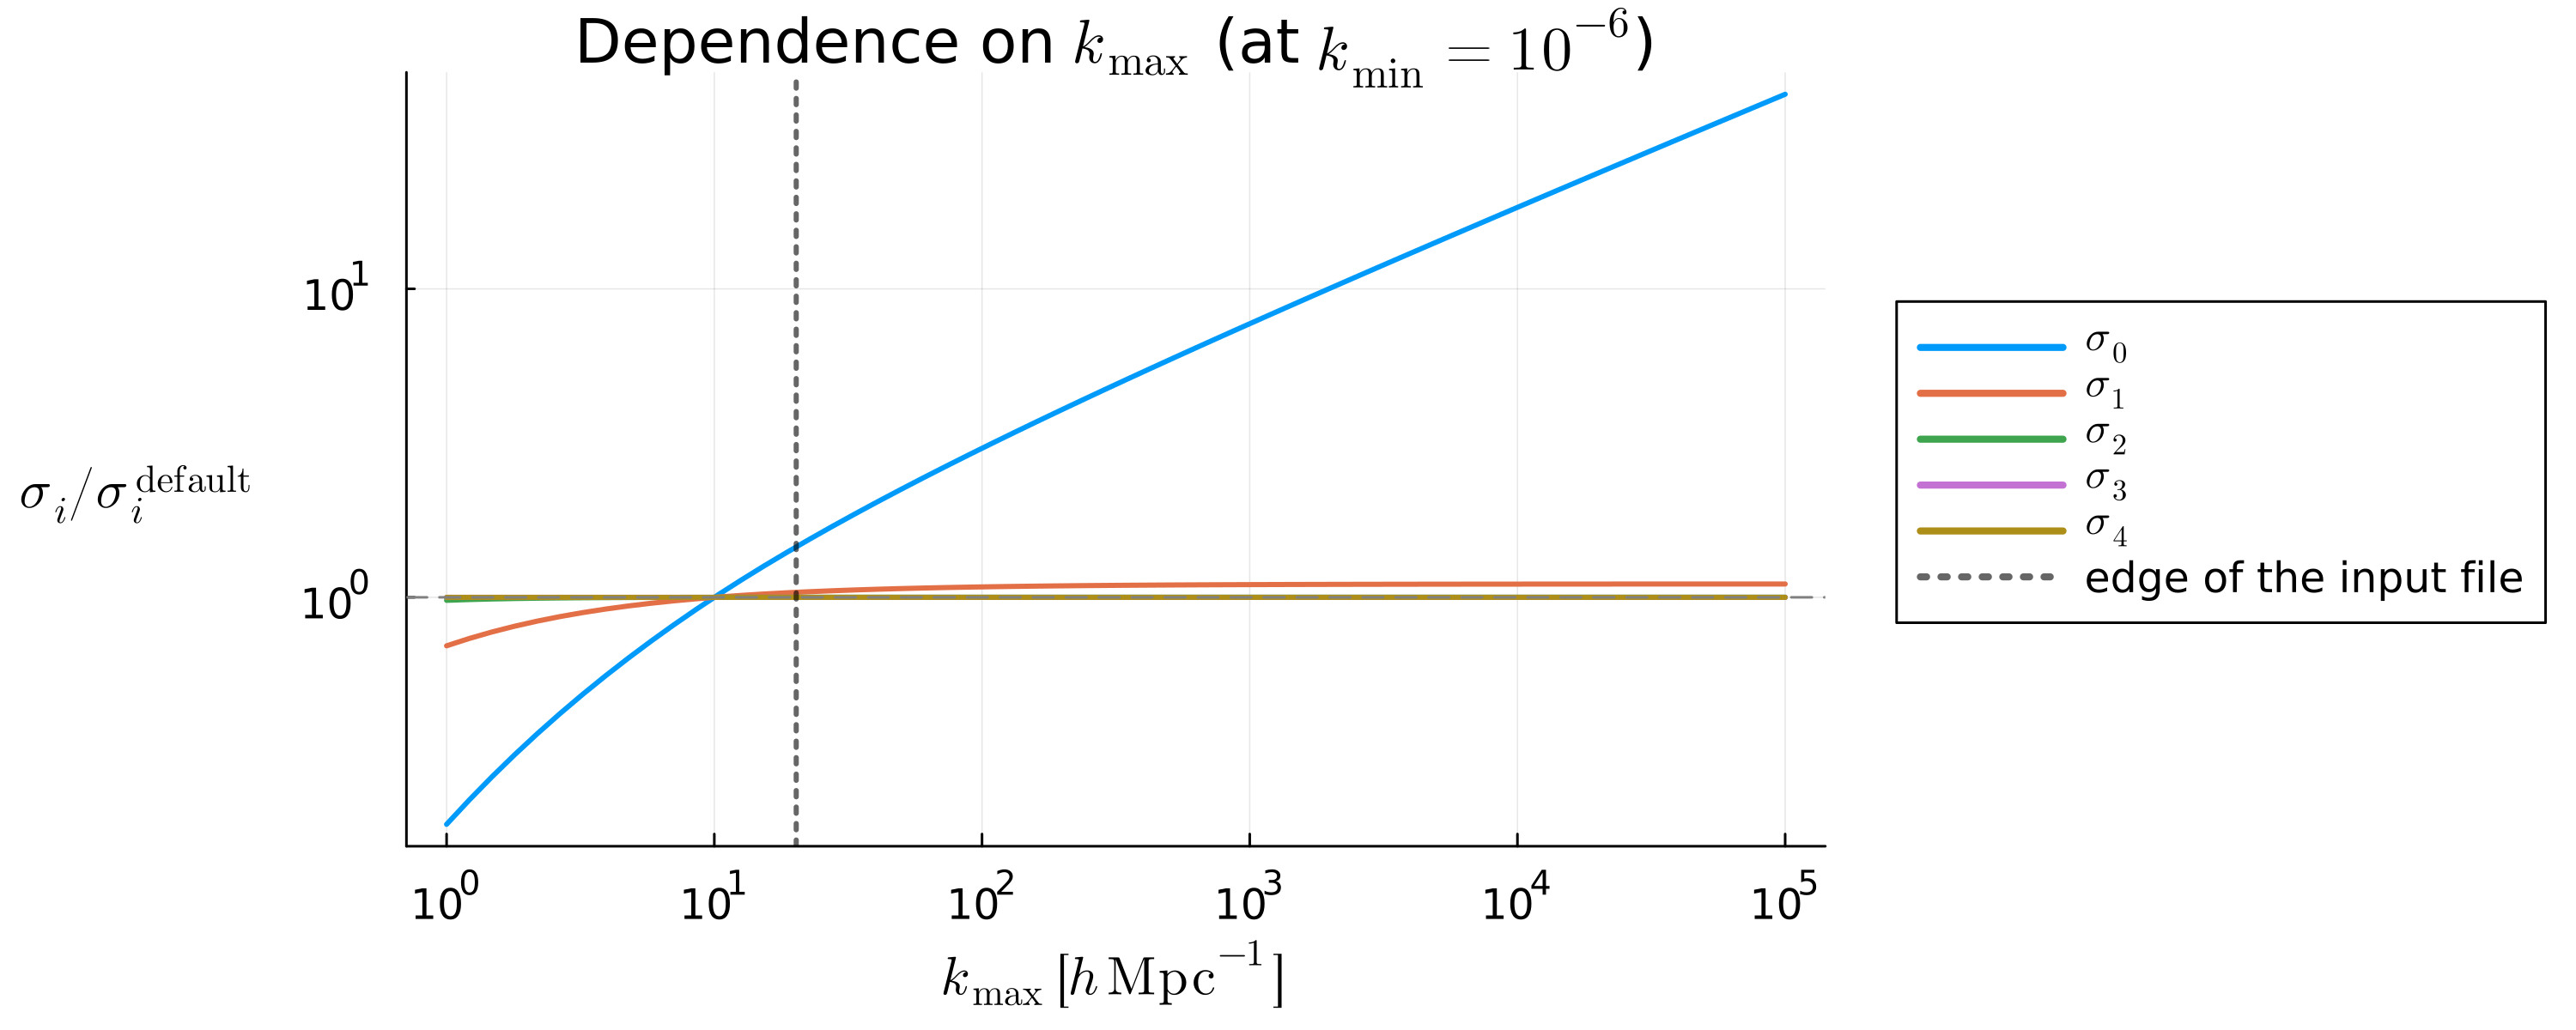

In [21]:
plot_sigma_vs_cut(which=:kmax)

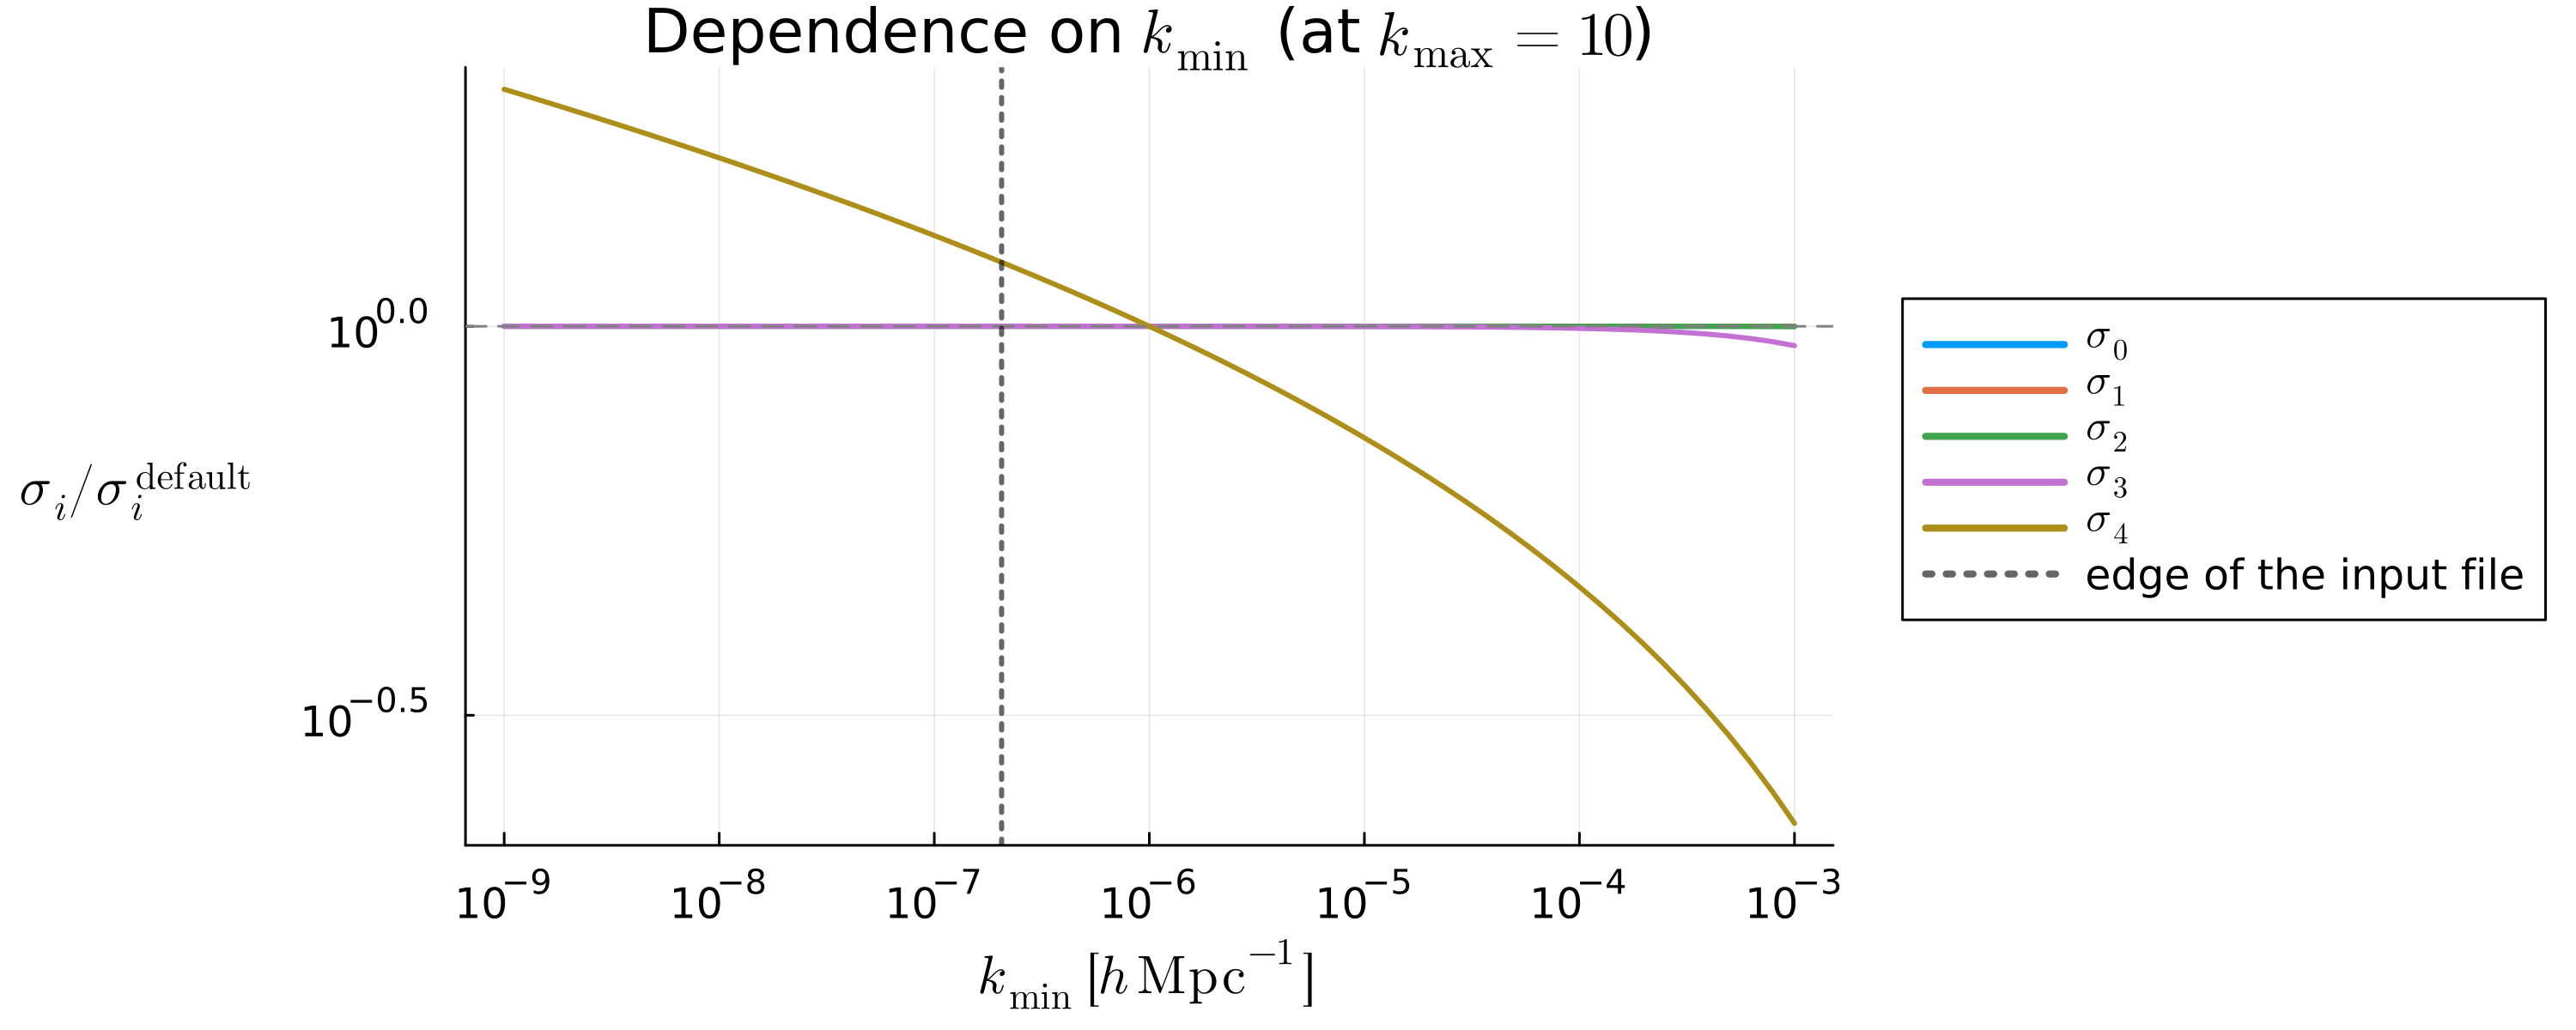

In [22]:
plot_sigma_vs_cut(which=:kmin)

## 3. The $I_\ell^n$ against the cut

Each integral divided by the same integral on `[1e-5, 1e3]`. The $s$ grid starts just
above `fit_min`, so these are the splines and not the extrapolations.

Above $s \simeq 2 \; h^{-1}\,$Mpc every range gives the same answer to the width of the
line: a $j_\ell(qs)$ with $s$ that large has already cancelled whatever happens beyond
$q \sim 1$. Below it the curves separate, and the separation is driven by
$k_\mathrm{max}$ alone - the $k_\mathrm{min} = 10^{-8}$ and $k_\mathrm{min} = 10^{-4}$
curves sit on top of each other. The oscillations are the ringing of the FFTLog at the
edge of its own $s$ grid.

Small $s$ is exactly where the $\Delta\chi \rightarrow 0$ limits live, so this is the
region that has to be consistent with the $\sigma_i$, and it is the region that moves.

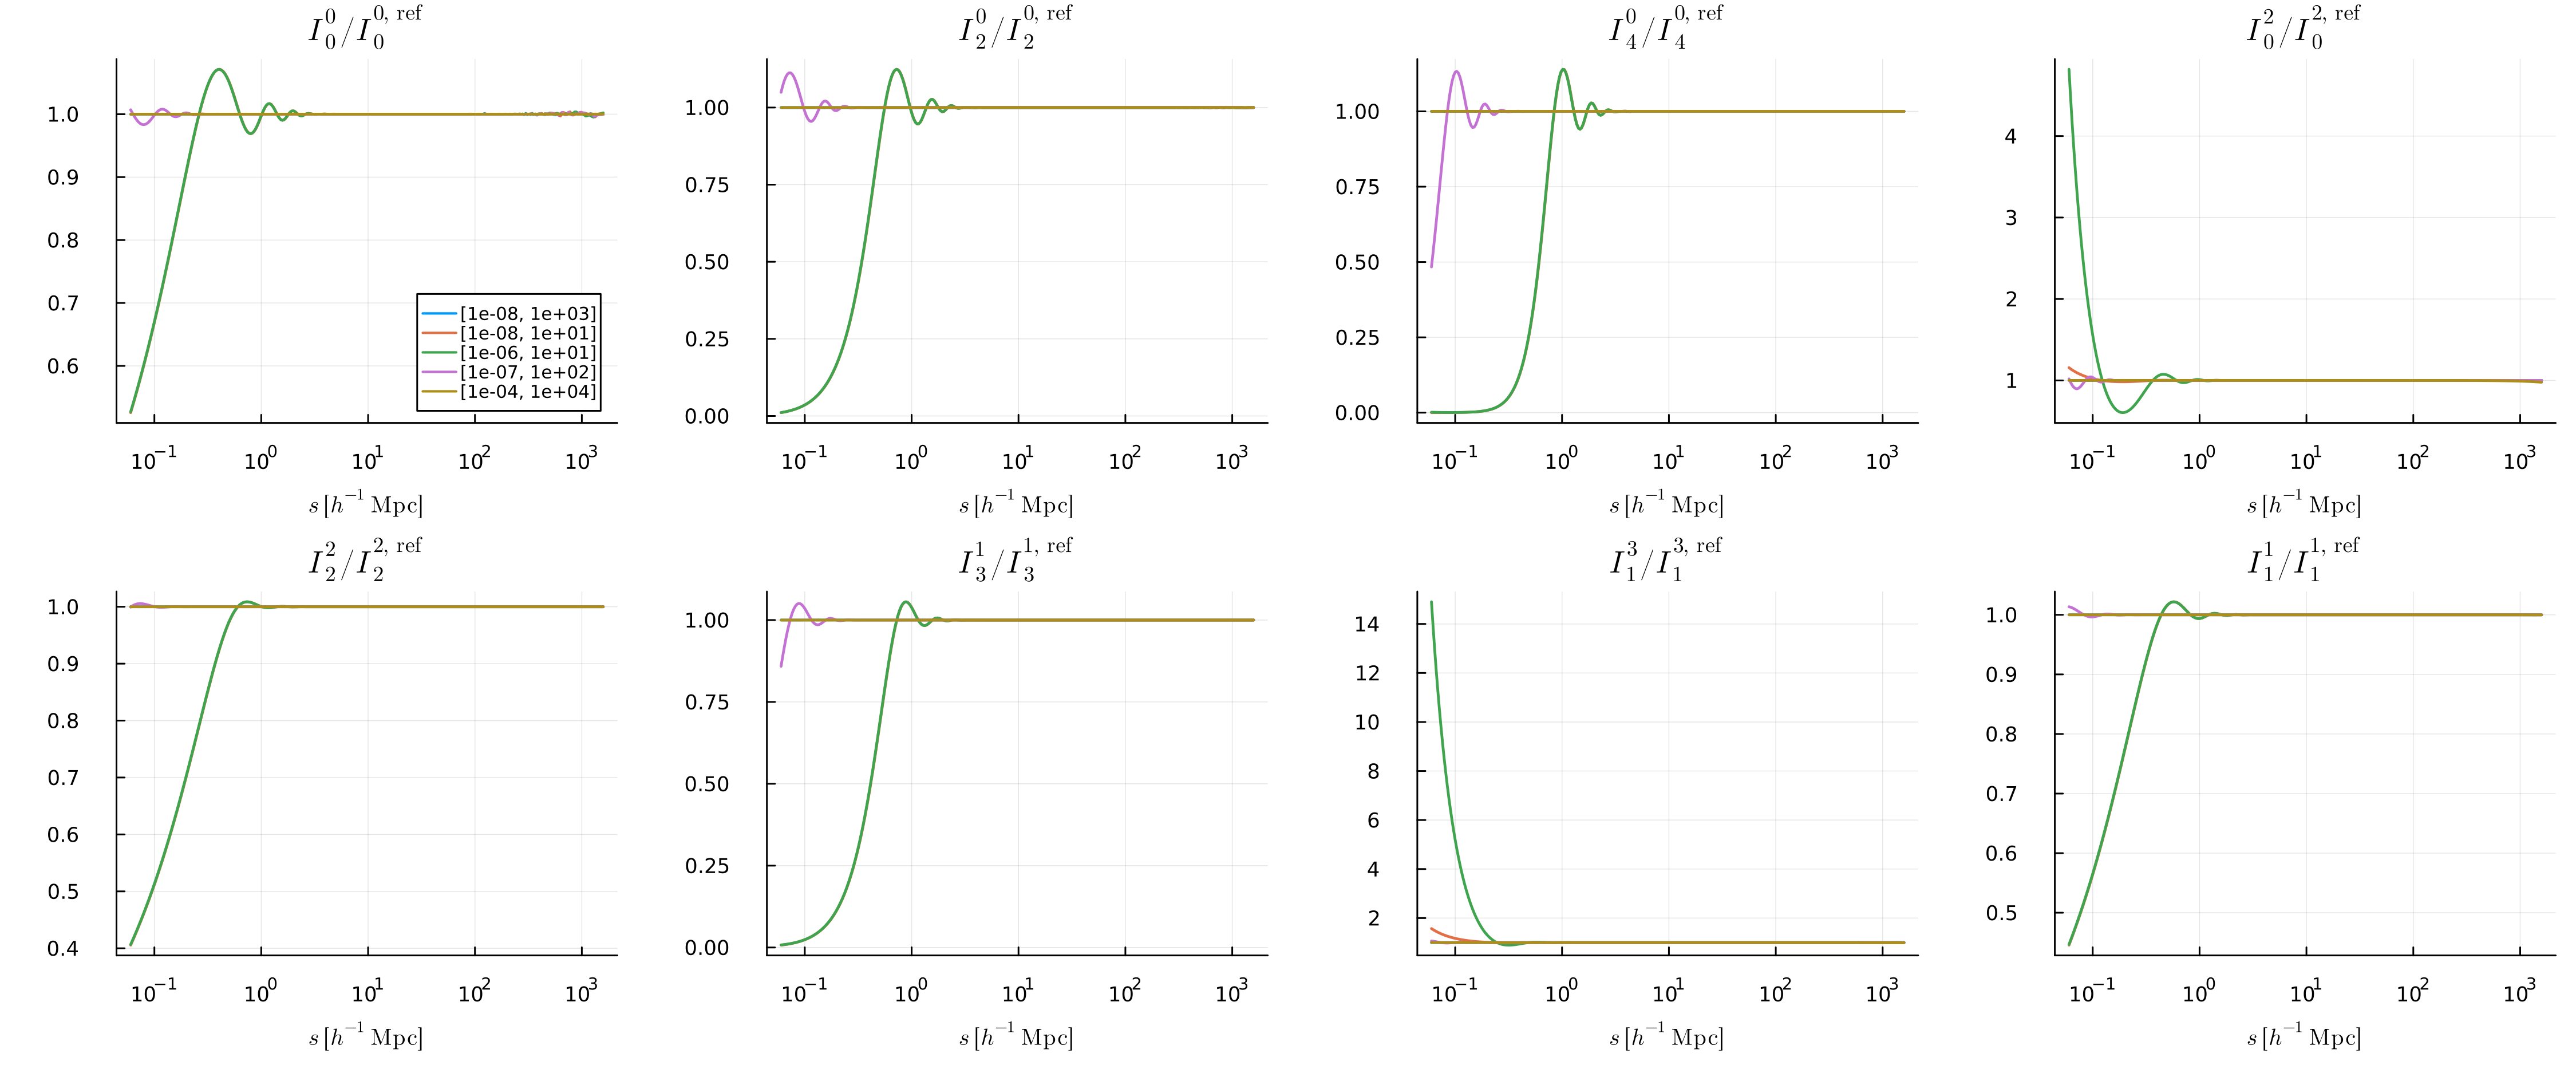

In [23]:
plot_Iln_ratio()

## 4. The left power-law fit, and where it breaks

This is the part to be afraid of.

Below `fit_min` the spline stops and `IntegralIPS` extrapolates with the power law it
fitted on `[fit_min, fit_max] = [0.05, 0.5]`. That window has to sit **inside the
power-law region** of $I_\ell^n(s)$. But $I_\ell^n$ saturates for $s \lesssim
1/k_\mathrm{max}$ - that is the whole point of $I_0^0(s) \rightarrow \sigma_0$ - so the
window is in the power-law region only while

\begin{equation*}
  \texttt{fit\_min} \; \gg \; \frac{1}{k_\mathrm{max}} \; .
\end{equation*}

With `fit_min = 0.05` that asks for $k_\mathrm{max} \gg 20$. The old hard-coded
$k_\mathrm{max} = 10^3$ satisfied it with two decades to spare; the default
$k_\mathrm{max} = 10$ does **not**, and `1/k_max = 0.1` falls right inside
`[0.05, 0.5]`.

The table below shows what happens. Read the `branch`, `l_a` and the last two columns:

In [24]:
table_left_fits()

k range            I_l^n         l_si          l_b          l_a   branch  spline(fmin) fit(0.9 fmin)
[1e-05, 1e+03]     I_0^0       -0.3824   1.3435e+01  -8.6876e+00       if    3.3497e+01    3.5287e+01
[1e-05, 1e+03]     I_2^2       -0.3682   1.1791e+00  -6.5470e-01       if    2.8959e+00    3.0391e+00
[1e-05, 1e+03]     I_1^1       -0.3723   5.3583e+00  -3.1519e+00       if    1.3178e+01    1.3847e+01
[1e-08, 1e+03]     I_0^0       -0.3827   1.3415e+01  -8.6640e+00       if    3.3498e+01    3.5290e+01
[1e-08, 1e+03]     I_2^2       -0.3683   1.1785e+00  -6.5400e-01       if    2.8960e+00    3.0392e+00
[1e-08, 1e+03]     I_1^1       -0.3725   5.3540e+00  -3.1468e+00       if    1.3179e+01    1.3847e+01
[1e-08, 1e+01]     I_0^0       -0.0000   5.9242e+04   0.0000e+00   elseif    1.6185e+01    5.9250e+04
[1e-08, 1e+01]     I_2^2       -0.0000   2.0747e+03   0.0000e+00   elseif    1.0831e+00    2.0750e+03
[1e-08, 1e+01]     I_1^1       -0.0000   1.3476e+04   0.0000e+00   elseif    5.4093

The rows with $k_\mathrm{max} \geq 10^2$ are healthy: `l_a` is non-zero, the branch is
`if`, and the fit matches the spline across `fit_min`. The rows with
$k_\mathrm{max} = 10$ are not: `l_si` is $0$ to four decimals, `l_a` is exactly $0$, and
the extrapolation returns $\sim 6 \times 10^4$ where the spline, one grid point higher,
returns $\sim 16$. **A factor $3 \cdot 10^3$ discontinuity, silently.**

The plot makes it visible. The dash-dotted lines are the $\sigma_0$ of each range, i.e.
the value $I_0^0$ must tend to:

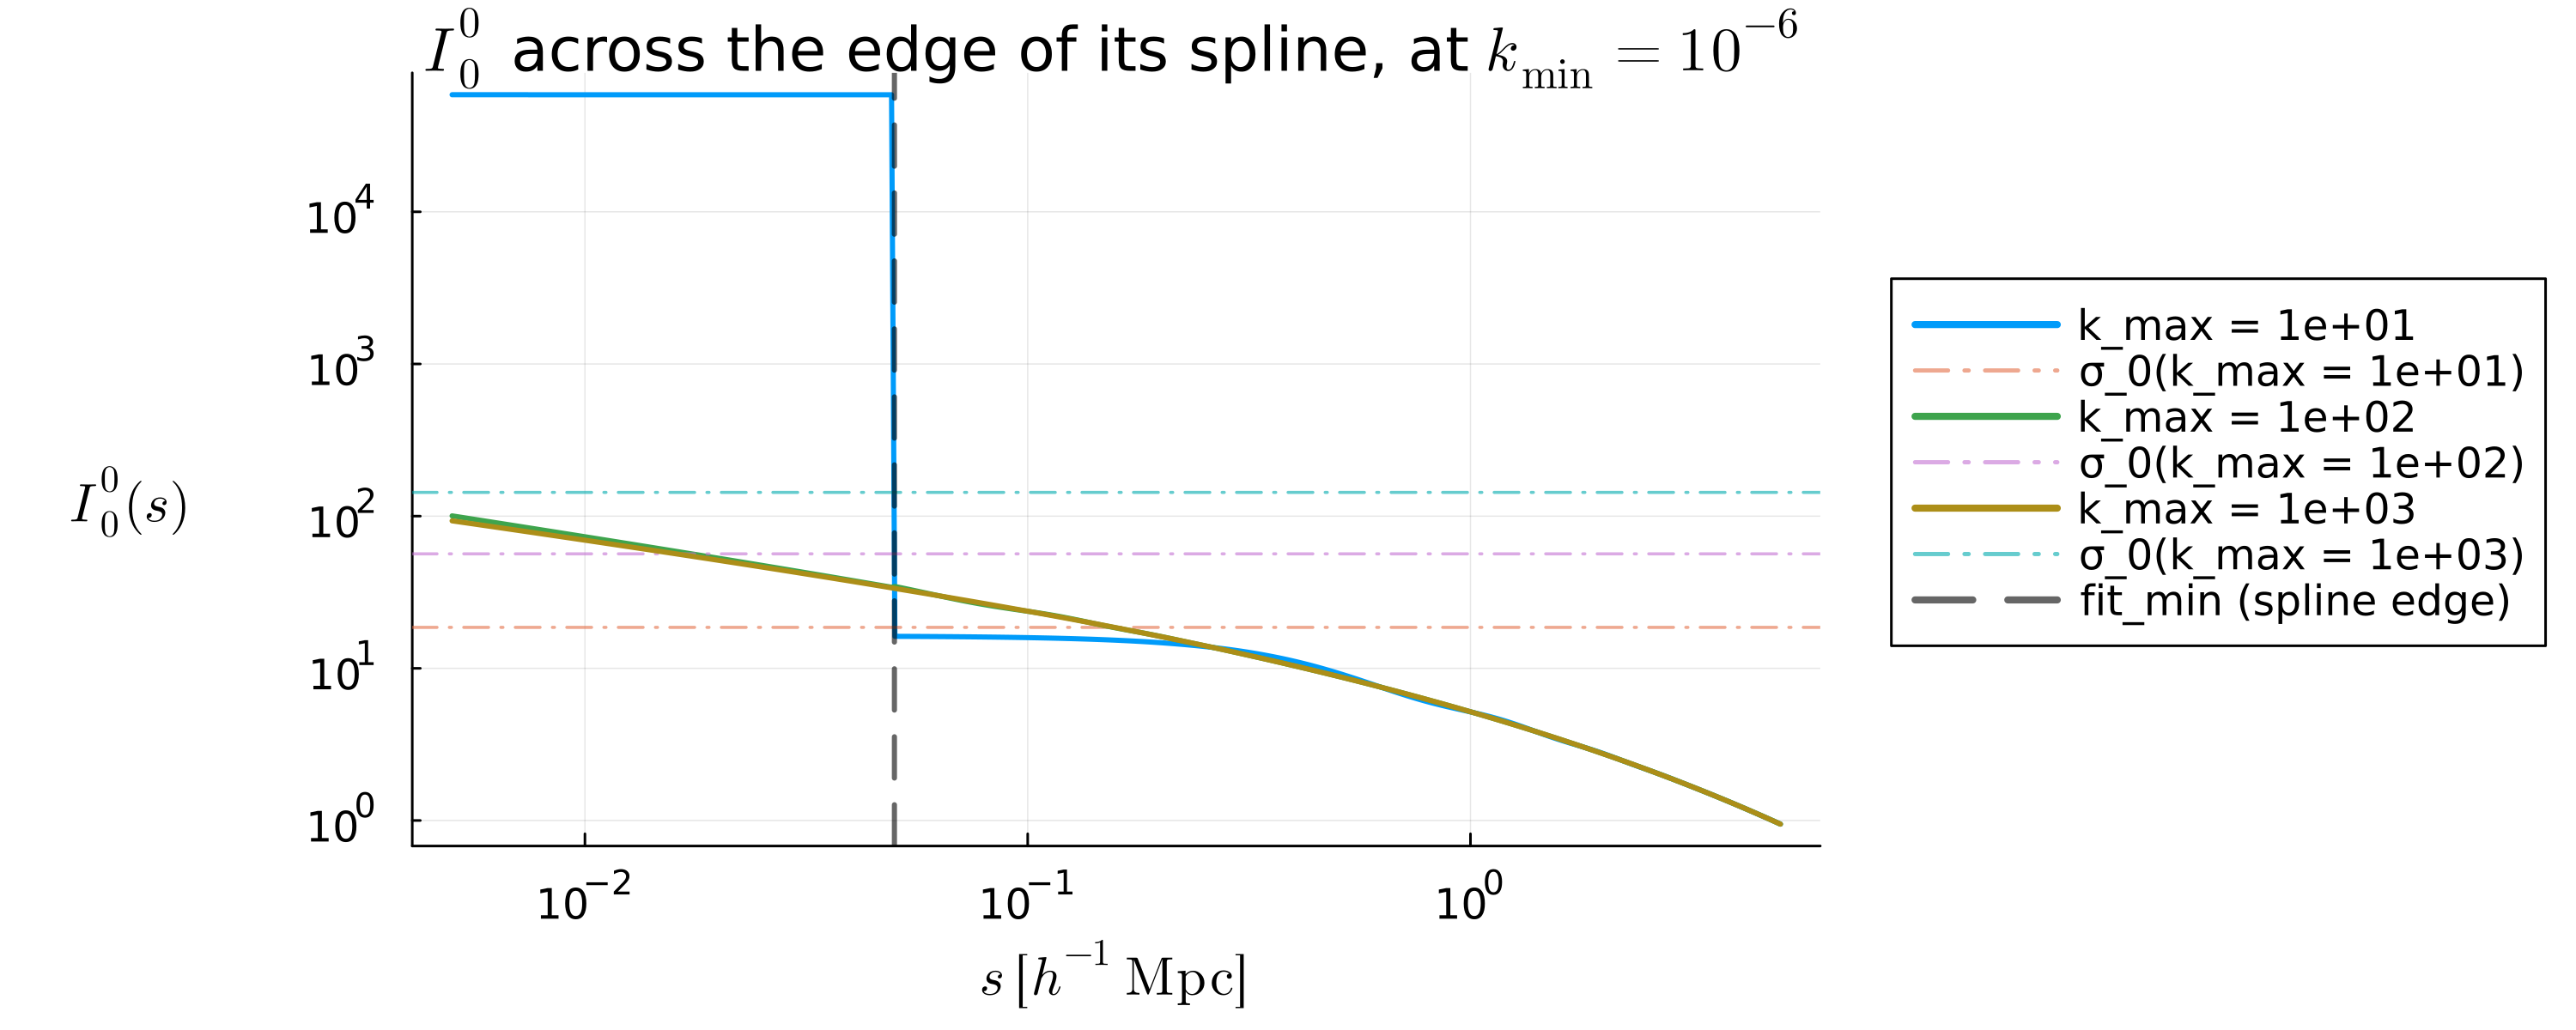

In [25]:
plot_left_edge()

Two separate things are visible here.

**The jump** on the $k_\mathrm{max} = 10$ curve, at `fit_min`. Its cause is in
`power_law_from_data` (`src/MathUtils.jl`), in the `con == true` branch. When the fit
window straddles the saturation knee, the three-parameter model $a + b \, s^{s_i}$
becomes degenerate: the fit converges to $s_i \simeq -4 \cdot 10^{-5}$, $b \simeq +3679$,
$a \simeq -3678$, i.e. it has found $a + b(1 + s_i \ln s)$, a straight line in $\ln s$,
in which $a$ and $b$ separately mean nothing. Their relative errors come back as $\pm
3200$. Two details then let it through:

* the relative errors are used **signed**. `all(x -> x < 0.05, pers_1)` and
  `pers_1[3] < 0.05` are both satisfied by a large *negative* relative error, which is
  exactly what a badly determined parameter gives. With `abs(...)` the degenerate fit
  would be rejected;
* the fall-back `curve_fit` calls are given the three-element `p0` against two-parameter
  models, so `vals_2` carries a spurious third entry and the destructuring
  `si, b, a = vcat(vals_2, vals_1[3])` takes `a = vals_2[3] = p0[3] = 0.0` - which is
  where the exact `l_a = 0` in the table comes from.

Neither is fixed on this branch: the signed comparison already fires on the *current*
defaults (with `[1e-5, 1e3]` the fit of $I_4^0$ is accepted with a 43% error on $a$), so
putting an `abs` in would move results that have nothing to do with $k_\mathrm{min}$ and
$k_\mathrm{max}$. It wants its own branch and its own regenerated reference files.

**The curves never flatten.** Even the healthy $k_\mathrm{max} = 10^3$ curve keeps
falling below `fit_min` instead of levelling off at its $\sigma_0$. A pure power law
cannot saturate, so the left extrapolation of $I_0^0$ is wrong for $s \ll
1/k_\mathrm{max}$ whatever the fit does; that is the region the analytic $\Delta\chi
\rightarrow 0$ limits exist to cover, and the reason they are worth having.

The window can be moved instead of the range. It has to go **up**, not down: below
$1/k_\mathrm{max}$ the integral is flat, and a flat dataset is the worst possible input
for $a + b \, s^{s_i}$. Holding $k_\mathrm{max} = 10$ and sliding the window:

In [26]:
table_fit_windows()

k_min = 1e-08, k_max = 1e+01  ->  saturation scale 1/k_max = 0.1
[fit_min, fit_max]         l_si          l_b          l_a  spline(fmin+)  fit(0.9 fmin)
[   5e-02,    5e-01]   -0.0000   5.9242e+04   0.0000e+00     1.6185e+01     5.9250e+04
[   2e-01,    2e+00]   -0.3031   1.6352e+01   0.0000e+00     1.4697e+01     2.7500e+01
[   5e-01,    5e+00]   -0.7318   6.0351e+00  -9.1008e-01     9.3371e+00     9.9161e+00
[   1e+00,    1e+01]   -0.8378   5.8346e+00  -5.4672e-01     5.1629e+00     5.8264e+00
[   2e+00,    2e+01]   -1.0251   6.1005e+00  -2.2198e-01     2.7461e+00     3.1176e+00


From `[0.5, 5]` upwards the fit is healthy again and continuous with the spline to a few
percent. It is not free, though: everything below `fit_min` is thrown away and replaced
by a power law, and a power law cannot flatten, so for $s \ll 1/k_\mathrm{max}$ the
extrapolation is wrong by construction however well it is fitted. Raising
$k_\mathrm{max}$ is the better of the two knobs.

## 5. The right edge of the spline

`xicalc` returns a logarithmic grid that starts at `s0` and spans as many decades as
$[k_\mathrm{min}, k_\mathrm{max}]$ does, and `IntegralIPS` takes its last-but-one point
as `right`, where its spline stops and the right power law starts. So the range also
decides the *upper* edge, and it moves by four orders of magnitude across the ranges
tried here:

In [27]:
table_right_edges()

k range              decades     right edge  r_si of I_0^0  r_si of I_2^2
[1e-05, 1e+03]           8.0     9.6466e+04         1.6784        -3.2512
[1e-08, 1e+03]          11.0     9.5173e+07        -0.0220        -0.0095
[1e-08, 1e+01]           9.0     9.6033e+05         0.0987        -1.0703
[1e-06, 1e+01]           7.0     9.6901e+03        -3.9924        -3.9557
[1e-07, 1e+02]           9.0     9.6033e+05         0.0302        -0.4158
[1e-04, 1e+04]           8.0     9.6466e+04        14.9341        -7.7188


This matters less than it looks - GaPSE asks for separations up to $\sim 2 s_\mathrm{max}$,
a few thousand $h^{-1}\,$Mpc, and every row above is comfortably past that - but the
fitted slope `r_si` is not stable at all, and a positive one means an extrapolation that
*grows* with $s$. Worth keeping `s0` and the range such that `right` stays well above the
largest separation of the survey.

## 6. What it costs on a TPCF

Four cosmologies and the one effect the $\Delta\chi \rightarrow 0$ limits dominate, the
GNC Lensing-Lensing auto-correlation. Three differ only by $k_\mathrm{max}$. The fourth
is the control: the same broken $k_\mathrm{max} = 10$ but with `con = false`, which
sends `power_law_from_data` down its two-parameter path and so replaces the degenerate
left fit with a healthy one, changing nothing else. If the 38% of section 4 were the
fit, that curve would move.

The build of each `Cosmology` takes about half a minute, so these are the slow cells.

In [28]:
const Z_MIN, Z_MAX = 0.05, 0.20

"""
    mkcosmo(kmin, kmax) :: GaPSE.Cosmology

A `Cosmology` identical to the one of the unit tests except for the `k_min`/`k_max`
pair, which now bounds the ``\\sigma_i``, the ``I_\\ell^n`` and the ``\\tilde{I}^4_0``
alike.
"""
function mkcosmo(kmin, kmax; fit_min=0.05, fit_max=0.5, con=true)
    params = GaPSE.CosmoParams(Z_MIN, Z_MAX, π / 2.0;
        Ω_b=0.0489, Ω_cdm=0.251020, h_0=0.7, s_lim=1e-2,
        b1=1.0, b2=nothing, s_b1=0.0, s_b2=nothing, 𝑓_evo1=0.0, 𝑓_evo2=nothing,
        IPS_opts=Dict(:fit_left_min => 1e-6, :fit_left_max => 3e-6,
            :fit_right_min => 1e1, :fit_right_max => 2e1),
        IPSTools_opts=Dict(:N => 1024, :fit_min => fit_min, :fit_max => fit_max,
            :con => con, :k_min => kmin, :k_max => kmax))
    GaPSE.Cosmology(params, FILE_BACKGROUND, FILE_PS, FILE_F_MAP, FILE_IF_MAP)
end;

In [29]:
const TPCF_KW = Dict(:use_windows => false, :enhancer => 1e8, :obs => :no,
    :N_trap => 30, :N_lob => 30, :N_χs => 40, :N_χs_2 => 20,
    :suit_sampling => true, :alg => :trap);
# label, k_max, con
const CASES = [
    ("k_max = 1e1", 1e1, true),
    ("k_max = 1e2", 1e2, true),
    ("k_max = 1e3", 1e3, true),
    ("k_max = 1e1, con = false", 1e1, false),
];
const REF_CASE = "k_max = 1e3";

const COSMOS = Dict(lab => mkcosmo(1e-8, km; con=c) for (lab, km, c) in CASES);
@printf("%-26s %14s %10s %14s %16s\n", "", "sigma_0", "l_si", "l_b", "I_0^0(0.045)")
for (lab, _, _) in CASES
    t = COSMOS[lab].tools
    @printf("%-26s %14.6e %10.5f %14.4e %16.4e\n", lab, t.σ_0, t.I00.l_si, t.I00.l_b,
        t.I00(0.045))
end

                                  sigma_0       l_si            l_b     I_0^0(0.045)
k_max = 1e1                  1.858428e+01   -0.00004     5.9242e+04       5.9250e+04
k_max = 1e2                  5.654162e+01   -0.43358     1.0776e+01       3.5765e+01
k_max = 1e3                  1.432850e+02   -0.38270     1.3415e+01       3.5290e+01
k_max = 1e1, con = false     1.858428e+01   -0.17475     1.0388e+01       1.7860e+01


In [30]:
const SS_TPCF = 10 .^ range(0, log10(2 * COSMOS[REF_CASE].s_max), length=24);
const XIS = Dict(lab => GaPSE.map_ξ_GNC_multipole(COSMOS[lab], "auto_lensing", SS_TPCF;
    L=0, pr=false, GaPSE.specif_kwargs_GNC("auto_lensing", TPCF_KW)...)[2]
    for (lab, _, _) in CASES);
println("done")

done


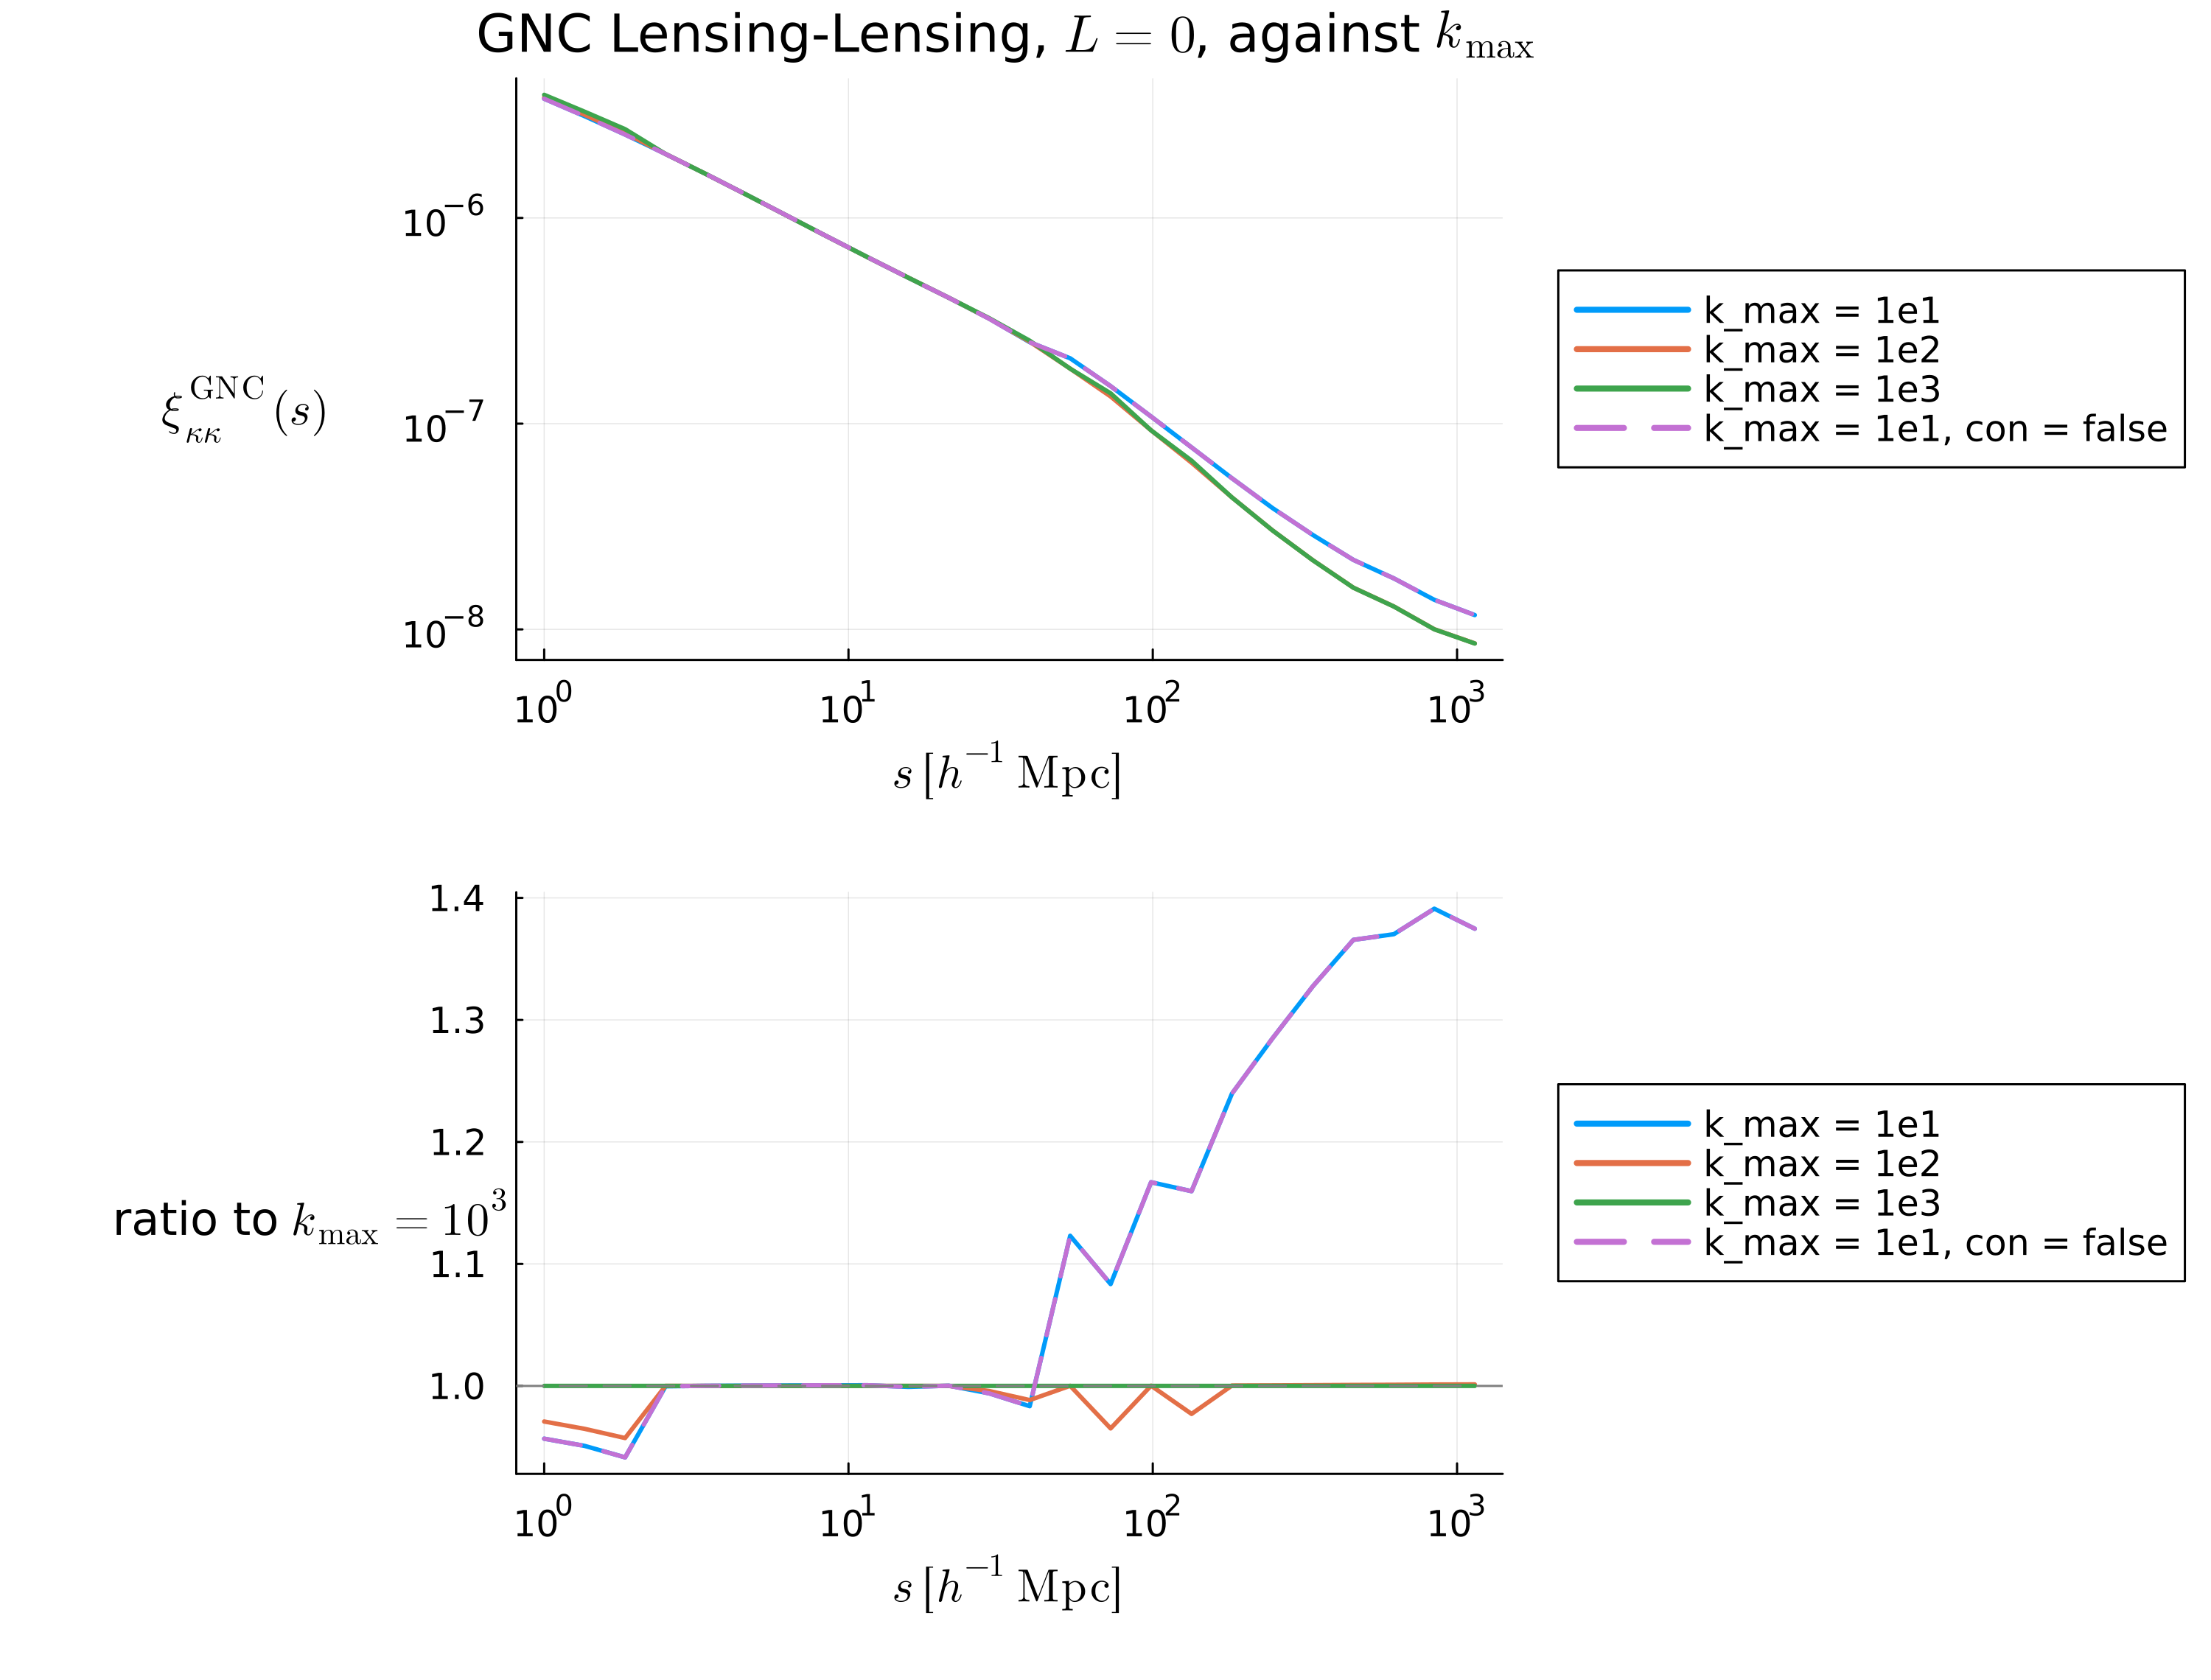

In [31]:
function plot_tpcf(; kwargs...)
    p1 = plot(; xscale=:log10, yscale=:log10,
        xlabel=L"s \; [h^{-1} \, \mathrm{Mpc}]",
        ylabel=L"\xi^{\,\mathrm{GNC}}_{\kappa \kappa}(s)" * " "^8,
        title="GNC Lensing-Lensing, " * L"L = 0" * ", against " * L"k_\mathrm{max}",
        yguidefontrotation=-90, xticks=logticks(SS_TPCF[1], SS_TPCF[end]),
        plot_kwargs(:left_margin => 38Plots.mm, :bottom_margin => 8Plots.mm, kwargs...)...)
    for (lab, _, _) in CASES
        plot!(p1, SS_TPCF, XIS[lab], lw=2, ls=(lab == CASES[end][1] ? :dash : :solid),
            label=lab)
    end
    p2 = plot(; xscale=:log10,
        xlabel=L"s \; [h^{-1} \, \mathrm{Mpc}]",
        ylabel="ratio to " * L"k_\mathrm{max} = 10^3" * " "^4,
        yguidefontrotation=-90, xticks=logticks(SS_TPCF[1], SS_TPCF[end]),
        plot_kwargs(:left_margin => 38Plots.mm, :bottom_margin => 8Plots.mm,
            :title => "", kwargs...)...)
    for (lab, _, _) in CASES
        plot!(p2, SS_TPCF, XIS[lab] ./ XIS[REF_CASE], lw=2,
            ls=(lab == CASES[end][1] ? :dash : :solid), label=lab)
    end
    hline!(p2, [1.0], ls=:dash, lw=1, c=:gray, label="")
    plot(p1, p2; layout=(2, 1), size=(1000, 760), dpi=300)
end;
plot_tpcf()

The $k_\mathrm{max} = 10$ curve sits up to **+39%** above the other two at
$s \simeq 10^3$, and $k_\mathrm{max} = 10^2$ and $10^3$ agree with each other to a few
percent. The dashed control curve - the same $k_\mathrm{max} = 10$ with the degenerate
left fit replaced by a healthy one - lies exactly on top of the solid blue, to the last
digit.

So the two things are separate, and it is worth being explicit about which is which:

* **the 38% is the range, not the fit.** It comes from the $I_\ell^n$ themselves at
  $s \lesssim 0.2$, inside their spline, where a $k_\mathrm{max}$ of 10 removes power
  that a $k_\mathrm{max}$ of $10^3$ keeps: $I_0^0(0.06)$ drops to 57%, $I_0^0(0.1)$ to
  70%, and by $s = 1$ the two agree to $2 \cdot 10^{-3}$. That region is what the
  $\Delta\chi \rightarrow 0$ switch feeds on, so Lensing-Lensing feels it and the
  others barely do - the GNC sum moves by 0.5%;
* **the degenerate fit is not reached by this observable.** It lives below
  `fit_min = 0.05`, and with `Δχ_min = 1e-1` these integrands never ask for an
  $I_\ell^n$ there - which is why the control curve does not move. That does not make it
  harmless: it is a $3 \cdot 10^3$ discontinuity waiting for the first caller that lowers
  `Δχ_min`, shrinks `s_min`, or raises `fit_min`.

The practical consequence for the unit tests: their reference files store the old mixed
convention, so unifying the range means regenerating them. It is a real change of the
numbers, not a cosmetic one, and the right order is to fix `power_law_from_data` first,
so that the regenerated files are not carrying a broken extrapolation with them.

## Save the plots and the data

In [32]:
save_plot(plot_sigma_vs_cut(which=:kmax), "sigma_vs_kmax.png");
save_plot(plot_sigma_vs_cut(which=:kmin), "sigma_vs_kmin.png");
save_plot(plot_Iln_ratio(), "Iln_ratios.png");
save_plot(plot_left_edge(), "I00_left_edge.png");
save_plot(plot_tpcf(), "lensing_vs_kmax.png");
open(joinpath(DIR, "kmin_kmax_tables.txt"), "w") do io
    table_two_ranges(io)
    println(io)
    table_left_fits(io)
    println(io)
    table_fit_windows(io)
    println(io)
    table_right_edges(io)
end
readdir(DIR)

6-element Vector{String}:
 "I00_left_edge.png"
 "Iln_ratios.png"
 "kmin_kmax_tables.txt"
 "lensing_vs_kmax.png"
 "sigma_vs_kmax.png"
 "sigma_vs_kmin.png"

## END